In [13]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

In [4]:
CLASSIFIED_FILE = "paper_other_classified2.jsonl"
OUTPUT_JSON     = "new_categories_analysis2.json"

rows = []
with open(CLASSIFIED_FILE, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))
print(f"Total rows : {len(rows):,}")

Total rows : 9,986


In [5]:

existing_rows = [r for r in rows if "category_keywords" not in r]
new_rows      = [r for r in rows if "category_keywords" in r]

cats_existing = Counter(r.get("category", "") for r in existing_rows)
cats_new      = Counter(r.get("category", "") for r in new_rows)
cats_all      = Counter(r.get("category", "") for r in rows)

print(f"Catégories existantes : {len(cats_existing)} types — {len(existing_rows):,} rows")
print(f"Nouvelles catégories  : {len(cats_new)} types — {len(new_rows):,} rows")

Catégories existantes : 25 types — 4,957 rows
Nouvelles catégories  : 3438 types — 5,029 rows


In [6]:
from collections import Counter

new_cats_counter = Counter(r.get('category','') for r in new_rows)
sorted_new = new_cats_counter.most_common()

print(f"Nouvelles catégories UNIQUES : {len(sorted_new)}\n")
print(f"{'CATEGORIE':<50} {'COUNT':>6}")
print("-" * 58)
for cat, count in sorted_new:
    print(f"{cat:<50} {count:>6}")

Nouvelles catégories UNIQUES : 3438

CATEGORIE                                           COUNT
----------------------------------------------------------
sample_preparation                                     55
chemical_analysis                                      33
enzyme_activity_assay                                  31
clinical_treatment                                     20
microbial_ecology                                      19
experimental_results                                   18
epidemiology                                           16
diagnostic_performance                                 16
metabolic_pathway                                      15
study_design                                           15
clinical_question                                      15
process_performance                                    15
clinical_case_report                                   14
literature_review                                      14
clinical_outcomes                 

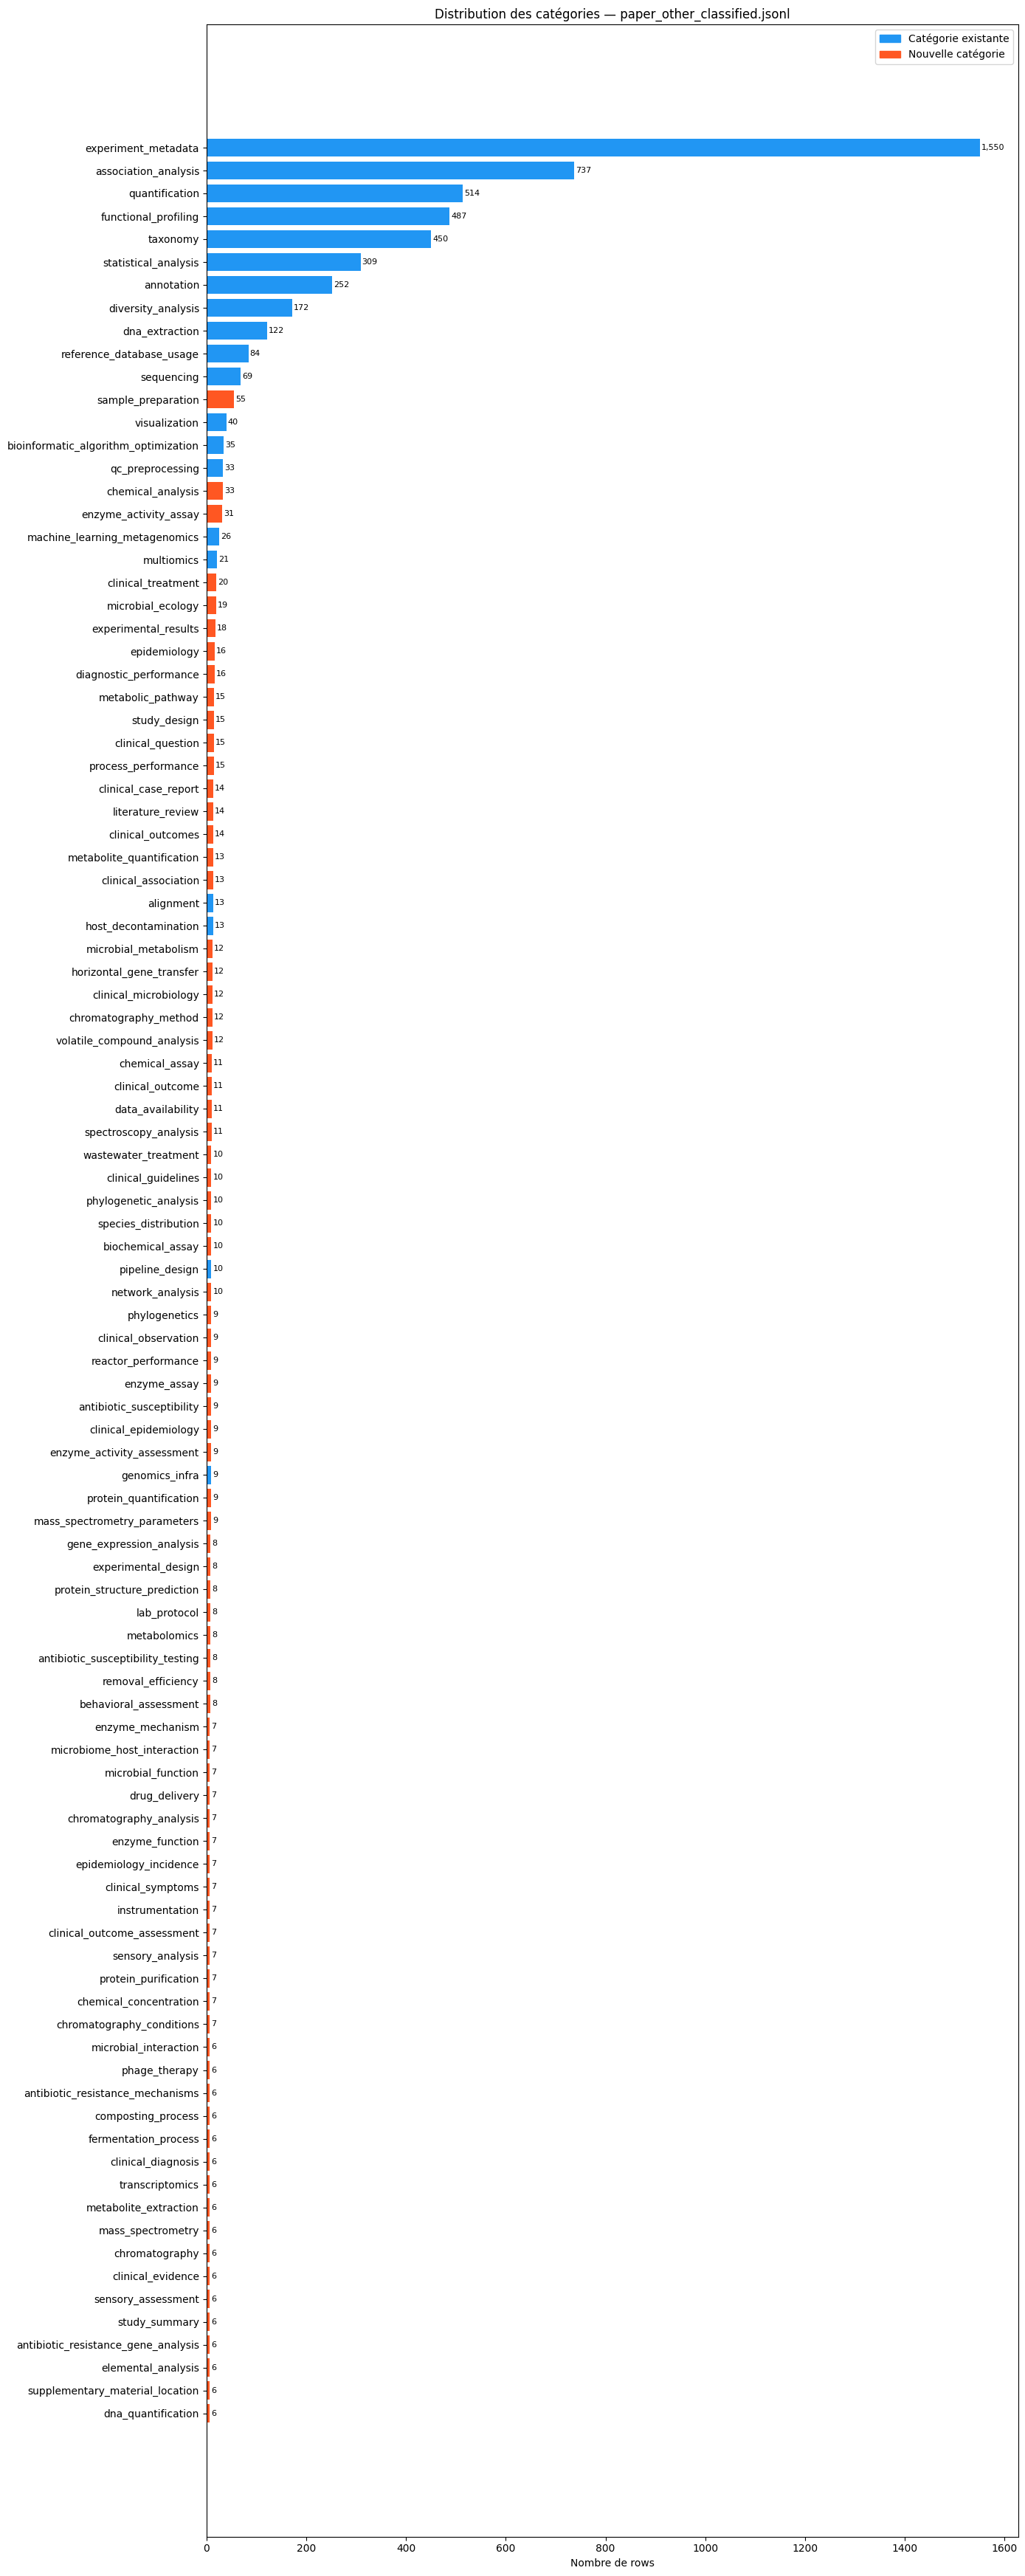

In [7]:
# Graphe — toutes les catégories
sorted_all = cats_all.most_common(100) 
labels     = [c[0] for c in sorted_all]
counts     = [c[1] for c in sorted_all]
colors     = ["#FF5722" if l in cats_new else "#2196F3" for l in labels]

fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.35)))
bars = ax.barh(labels[::-1], counts[::-1], color=colors[::-1])
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va="center", fontsize=8)
ax.set_xlabel("Nombre de rows")
ax.set_title("Distribution des catégories — paper_other_classified.jsonl")
blue = mpatches.Patch(color="#2196F3", label="Catégorie existante")
red  = mpatches.Patch(color="#FF5722", label="Nouvelle catégorie")
ax.legend(handles=[blue, red])
plt.tight_layout()
plt.savefig("classified_distribution.png", dpi=150)
plt.show()

In [8]:

new_cat_keywords = {}
for r in new_rows:
    cat = r.get("category", "")
    kws = r.get("category_keywords", [])
    if cat and cat not in new_cat_keywords:
        new_cat_keywords[cat] = kws

print(f"Nouvelles catégories détectées : {len(new_cat_keywords)}\n")
for cat, kws in sorted(new_cat_keywords.items()):
    print(f"  ➤  {cat:<40} ({cats_new[cat]} rows)")
    print(f"     keywords: {kws}")

Nouvelles catégories détectées : 3438

  ➤  abscisic_acid_signaling                  (1 rows)
     keywords: ['abscisic acid', 'mammalian intestine', 'signaling molecule', 'immunity', 'metabolism']
  ➤  absolute_configuration_assignment        (1 rows)
     keywords: ['absolute configurations', 'ECD spectra', 'experimental measured', 'calculated spectra', 'assigning absolute configurations', 'chiroptical comparison']
  ➤  absorbance_measurement                   (1 rows)
     keywords: ['absorbance', 'microplate reader', 'OD 450', 'measurement']
  ➤  acid_concentration_measurement           (1 rows)
     keywords: ['acid concentration', 'titration', 'sodium hydroxide', 'lactic acid']
  ➤  acid_effect_on_ph                        (1 rows)
     keywords: ['organic acid', 'lactic acid', 'pH', 'decrease']
  ➤  acid_mine_drainage_characteristics       (1 rows)
     keywords: ['acid mine drainage', 'acid pH', 'dissolved metals', 'metalloids', 'sulfates', 'ecosystems']
  ➤  acid_mine_drainage

Total      : 9,986
Existantes : 4,957 (49.6%)
Nouvelles  : 5,029 (50.4%)


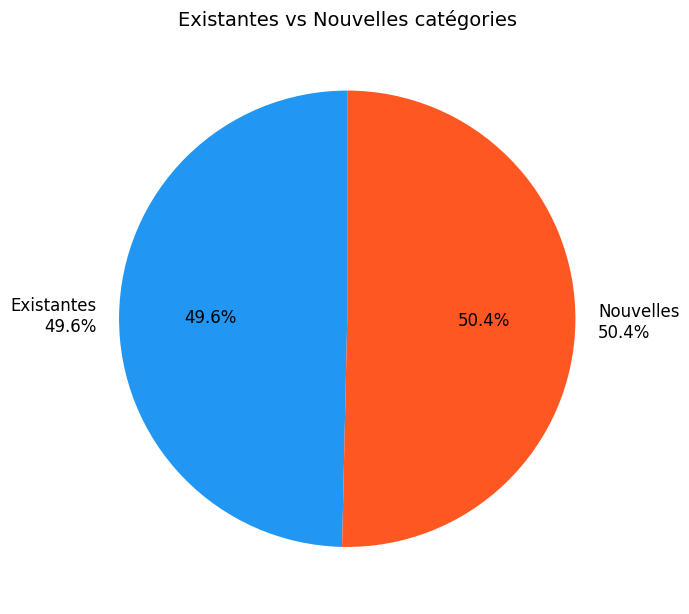

In [9]:

total     = len(rows)
pct_exist = len(existing_rows) / total * 100
pct_new   = len(new_rows)      / total * 100

print(f"Total      : {total:,}")
print(f"Existantes : {len(existing_rows):,} ({pct_exist:.1f}%)")
print(f"Nouvelles  : {len(new_rows):,} ({pct_new:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [len(existing_rows), len(new_rows)],
    labels=[f"Existantes\n{pct_exist:.1f}%", f"Nouvelles\n{pct_new:.1f}%"],
    colors=["#2196F3", "#FF5722"],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 12}
)
ax.set_title("Existantes vs Nouvelles catégories", fontsize=14)
plt.tight_layout()
plt.savefig("categories_pie.png", dpi=150)
plt.show()

In [10]:
# Nouvelles catégories uniques groupées avec leurs keywords
new_cat_keywords_grouped = {}
for r in new_rows:
    cat = r.get("category", "")
    kws = r.get("category_keywords", [])
    if cat:
        if cat not in new_cat_keywords_grouped:
            new_cat_keywords_grouped[cat] = {"count": 0, "keywords": kws}
        new_cat_keywords_grouped[cat]["count"] += 1

output = {
    "summary": {
        "total"         : total,
        "existing_count": len(existing_rows), "existing_pct": round(pct_exist, 2),
        "new_count"     : len(new_rows),      "new_pct"     : round(pct_new, 2),
        "unique_new_categories": len(new_cat_keywords_grouped)
    },
    "new_categories": dict(sorted(new_cat_keywords_grouped.items(), 
                                  key=lambda x: x[1]["count"], reverse=True)),
    "all_distribution": dict(cats_all.most_common())
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"✅ Sauvegardé : {OUTPUT_JSON}")
print(json.dumps(output["summary"], indent=2))

✅ Sauvegardé : new_categories_analysis2.json
{
  "total": 9986,
  "existing_count": 4957,
  "existing_pct": 49.64,
  "new_count": 5029,
  "new_pct": 50.36,
  "unique_new_categories": 3438
}


In [12]:
# Nouvelles catégories uniques groupées avec leurs keywords — filtre COUNT >= 20
new_cat_keywords_grouped = {}
for r in new_rows:
    cat = r.get("category", "")
    kws = r.get("category_keywords", [])
    if cat:
        if cat not in new_cat_keywords_grouped:
            new_cat_keywords_grouped[cat] = {"count": 0, "keywords": kws}
        new_cat_keywords_grouped[cat]["count"] += 1

# Filtre >= 20
filtered = {
    cat: data for cat, data in new_cat_keywords_grouped.items()
    if data["count"] >= 15
}
filtered_sorted = dict(sorted(filtered.items(), key=lambda x: x[1]["count"], reverse=True))

output = {
    "summary": {
        "total"                  : total,
        "existing_count"         : len(existing_rows), "existing_pct": round(pct_exist, 2),
        "new_count"              : len(new_rows),      "new_pct"     : round(pct_new, 2),
        "unique_new_categories"  : len(new_cat_keywords_grouped),
        "unique_new_filtered_20" : len(filtered_sorted)
    },
    "new_categories": filtered_sorted
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"✅ Sauvegardé : {OUTPUT_JSON}")
print(json.dumps(output["summary"], indent=2))

✅ Sauvegardé : new_categories_analysis2.json
{
  "total": 9986,
  "existing_count": 4957,
  "existing_pct": 49.64,
  "new_count": 5029,
  "new_pct": 50.36,
  "unique_new_categories": 3438,
  "unique_new_filtered_20": 12
}


In [18]:
# Charger les catégories validées
VALIDATED_JSON = "category_validated.json"

with open(VALIDATED_JSON, encoding="utf-8") as f:
    validated_data = json.load(f)

validated_cats = set(validated_data["new_categories"].keys())
print(f"Catégories validées à garder : {len(validated_cats)}")
for cat in sorted(validated_cats):
    print(f"   {cat}")

# Combiner les fichiers
FILES = [
    "C:/Users/PC/Downloads/genomeer/datasets/paper_other_classified1.jsonl",
    "C:/Users/PC/Downloads/genomeer/datasets/paper_other_classified2.jsonl",
    "C:/Users/PC/Downloads/genomeer/datasets/paper_non_other1.jsonl",
    "C:/Users/PC/Downloads/genomeer/datasets/paper_non_other2.jsonl",
]
OUTPUT_COMBINED = "C:/Users/PC/Downloads/genomeer/datasets/paper_combined_final.jsonl"

combined = []
skipped  = 0

for path in FILES:
    if not os.path.exists(path):
        print(f"[WARN] introuvable : {path}")
        continue
    count = 0
    with open(path, encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            cat = row.get("category", "")

            if "category_keywords" in row:
                if cat not in validated_cats:
                    skipped += 1
                    continue
                row.pop("category_keywords", None)
                row["quality"] = "second_stage"

            combined.append(row)
            count += 1
    print(f"  {path:<60} → {count:,} rows gardés")
os.makedirs(os.path.dirname(OUTPUT_COMBINED), exist_ok=True)
with open(OUTPUT_COMBINED, "w", encoding="utf-8") as f:
    for row in combined:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"\n Total combiné : {len(combined):,} rows → {OUTPUT_COMBINED}")
print(f"   Rows ignorés (nouvelle cat non validée) : {skipped:,}")

Catégories validées à garder : 3
   microbial_ecology
   microbiome_host_interaction
   sample_preparation
  C:/Users/PC/Downloads/genomeer/datasets/paper_other_classified1.jsonl → 7,669 rows gardés
  C:/Users/PC/Downloads/genomeer/datasets/paper_other_classified2.jsonl → 5,038 rows gardés
  C:/Users/PC/Downloads/genomeer/datasets/paper_non_other1.jsonl → 10,103 rows gardés
  C:/Users/PC/Downloads/genomeer/datasets/paper_non_other2.jsonl → 8,826 rows gardés

 Total combiné : 31,636 rows → C:/Users/PC/Downloads/genomeer/datasets/paper_combined_final.jsonl
   Rows ignorés (nouvelle cat non validée) : 12,682
